# PGD Adversarial Training on CIFAR-10

Trains a ResNet-18 with projected gradient descent adversarial training (Madry et al., ICLR 2018), evaluates the
selected checkpoint under the same protocol as the naturally trained baseline, and runs the obfuscated-gradient sanity
checks on the result.

## Prerequisites

1. **Accelerator: GPU.** Cell 1 fails on CPU. A k-step PGD attack needs k forward and backward passes per batch plus one
   for the parameter update, so adversarial training costs roughly eight times standard training: one to two hours on a
   T4, and considerably longer than a session allows on CPU.
2. **Two datasets attached.** The toolkit source, archived so that `attacks/`, `defenses/`, `experiments/` and `models/`
   sit at the top level; and CIFAR-10, archived so that `cifar-10-batches-py` sits at the top level. Cells 3 and 4
   locate both automatically.
3. **Internet**, required only when no CIFAR-10 dataset is attached, in which case cell 3 downloads it. That download
   runs at roughly 60 kB/s from this host and repeats every session, so attaching the data is worth the one-off upload.

## Design notes

**Imported rather than inlined.** The attack and training implementations are imported from the attached source instead
of pasted into cells, so a single version of each exists. A copy inlined into a notebook can diverge from the tested
implementation without anything failing, and an attack that is subtly wrong still returns correctly shaped tensors
inside the perturbation budget.

**What selection is based on.** Checkpoint selection uses robust accuracy on a 5,000-image split held out of the
training set. The test set is untouched until the final evaluation cell. Selecting on the test set would leak test
information into model selection and the reported figure would no longer be held out.

**Recovery.** There is no resume path. The history CSV is flushed every epoch and the best checkpoint is rewritten
whenever it improves, both under `/kaggle/working`, so an interrupted session still leaves usable artefacts.

## 1. Environment

In [1]:
import os
import platform
import sys
from pathlib import Path

import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "No CUDA device. Set Accelerator to GPU in the notebook settings. This run costs roughly eight times "
        "standard training and is not viable on CPU."
    )

DEVICE = torch.device("cuda")

print(f"python       {platform.python_version()}")
print(f"torch        {torch.__version__}  (cuda {torch.version.cuda})")
print(f"gpu          {torch.cuda.get_device_name(0)}, "
      f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"cpu count    {os.cpu_count()}")

python       3.12.13
torch        2.10.0+cu128  (cuda 12.8)
gpu          Tesla T4, 15.6 GB
cpu count    4


## 2. Configuration

`SMOKE` runs a two-epoch job on 1,000 training images to prove the path works before committing GPU hours. Run it once,
confirm the verification cell lists every file, then set `SMOKE = False` and run again. The two modes write to separate
directories so a smoke checkpoint of near-random weights can never be mistaken for a trained one.

`TrainConfig` is the single source of truth for hyperparameters: it validates its own arguments and serialises itself to
JSON beside the results, so there is no second copy to drift.

**On the epoch budget.** Madry and Rice both train for 200 epochs with decays at 100 and 150. Thirty epochs with decays
at the same fractions is a demonstration budget: it is enough to show robust overfitting, since that appears shortly
after the first decay, and it will land below published numbers. If GPU quota allows, 60 epochs gives a more
representative curve for roughly double the time.

**On `num_workers`.** Two is conservative for a four-vCPU Kaggle instance. Raise it to 3 if the GPU appears to be
waiting on data; the Windows default of zero would leave the T4 idle.

In [2]:
SMOKE = True

WORKING_ROOT = Path("/kaggle/working")
INPUT_ROOT = Path("/kaggle/input")
DOWNLOAD_ROOT = Path("/kaggle/temp/data")  # fallback only; scratch, not saved as notebook output
RUN_NAME = "smoke" if SMOKE else "pgd_at_30ep"
OUT_DIR = WORKING_ROOT / "results" / RUN_NAME
CKPT_DIR = WORKING_ROOT / "checkpoints" / RUN_NAME

# Passed to TrainConfig; anything absent keeps the reviewed module default.
REAL_OVERRIDES = {
    "epochs": 30,
    "batch_size": 128,
    "num_workers": 2,
    "device": "cuda",
}

SMOKE_OVERRIDES = {
    "epochs": 2,
    "batch_size": 128,
    "attack_steps": 2,
    "val_attack_steps": 2,
    "val_size": 49000,        # leaves 1,000 training images
    "val_eval_samples": 256,
    "lr_milestones": (0.5,),
    "num_workers": 2,
    "device": "cuda",
}

OVERRIDES = SMOKE_OVERRIDES if SMOKE else REAL_OVERRIDES

print(f"mode      {'SMOKE' if SMOKE else 'FULL'}")
print(f"outputs   {OUT_DIR}")
print(f"ckpts     {CKPT_DIR}")

mode      SMOKE
outputs   /kaggle/working/results/smoke
ckpts     /kaggle/working/checkpoints/smoke


## 3. Data

The toolkit disables torchvision's downloader, because the certificate on the development machine is expired and the
local copy is authoritative there. This cell resolves the data without modifying the reviewed module.

**Attach a CIFAR-10 dataset.** Zip the `cifar-10-batches-py` directory you already have locally and upload it as a
private dataset. The cell finds it and points `CIFAR10_DATA_ROOT` at it directly, with no copy and no download, since
`/kaggle/input` is readable and the loader only reads.

**The fallback exists but is slow.** Downloading from this host runs at roughly 60 kB/s, so 170 MB takes around
45 minutes, and `/kaggle/temp` is scratch, so it would repeat every session. Attaching the dataset makes this cell
instant and removes a dependency on an external host during a paid GPU session.

In [3]:
from torchvision.datasets import CIFAR10

CIFAR_MARKER = "cifar-10-batches-py"
REQUIRED = ("data_batch_1", "test_batch", "batches.meta")


def cifar_roots(root: Path, max_depth: int = 4) -> list[Path]:
    """Directories D for which D/cifar-10-batches-py holds the real batch files.

    Matching on the batch files rather than on the directory name matters: Kaggle exposes each
    dataset both at /kaggle/input/<slug> and under /kaggle/input/datasets/<owner>/<slug>, so a
    dataset whose slug equals the marker name produces a directory that looks like a hit and is
    one nesting level short. Duplicates are removed by resolved path, since the two exposures
    point at the same data.
    """
    found: list[Path] = []
    seen: set[Path] = set()
    frontier = [(root, 0)]
    while frontier:
        directory, depth = frontier.pop()
        if all((directory / CIFAR_MARKER / name).is_file() for name in REQUIRED):
            resolved = directory.resolve()
            if resolved not in seen:
                seen.add(resolved)
                found.append(directory)
            continue
        if depth >= max_depth:
            continue
        try:
            frontier.extend((child, depth + 1) for child in directory.iterdir() if child.is_dir())
        except PermissionError:
            continue
    return found


DATA_ROOT = None
for candidate in cifar_roots(INPUT_ROOT):
    try:
        # Constructing verifies the MD5 of every batch file against torchvision's canonical values.
        CIFAR10(root=str(candidate), train=False, download=False)
    except RuntimeError as error:
        print(f"rejected {candidate}: {error}")
        continue
    DATA_ROOT = candidate
    print(f"using attached dataset: {DATA_ROOT}")
    break

if DATA_ROOT is None:
    print("No usable CIFAR-10 dataset under /kaggle/input. Directories seen:")
    for directory in sorted(p for p in INPUT_ROOT.glob("*/*") if p.is_dir()):
        print(f"  {directory}")
    print("Falling back to download: roughly 45 minutes at this host's throughput, repeated every "
          "session because /kaggle/temp is scratch.")
    DATA_ROOT = DOWNLOAD_ROOT
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    CIFAR10(root=str(DATA_ROOT), train=True, download=True)
    CIFAR10(root=str(DATA_ROOT), train=False, download=True)

train_size = len(CIFAR10(root=str(DATA_ROOT), train=True, download=False))
test_size = len(CIFAR10(root=str(DATA_ROOT), train=False, download=False))
if (train_size, test_size) != (50_000, 10_000):
    raise RuntimeError(f"Expected 50000/10000 train/test images, found {train_size}/{test_size}.")

os.environ["CIFAR10_DATA_ROOT"] = str(DATA_ROOT)
print(f"CIFAR10_DATA_ROOT = {DATA_ROOT}  ({train_size} train, {test_size} test)")

using attached dataset: /kaggle/input/datasets/mendelowitzadi/cifar-10-batches-py
CIFAR10_DATA_ROOT = /kaggle/input/datasets/mendelowitzadi/cifar-10-batches-py  (50000 train, 10000 test)


## 4. Toolkit

The dataset directory is located by searching for `defenses/adversarial_training.py`, which tolerates both a flat
archive and one wrapped in an extra folder. The signature assertions and source hashes exist so that an outdated upload
fails in seconds rather than after an hour of training against a stale attack. Record the printed hashes with any result
you report.

`_common.py` anchors its default paths with `parents[2]`, which resolves to a path that does not exist here. That is
harmless: the defaults are consulted only when the environment variables are absent, and `CIFAR10_DATA_ROOT` is set.

In [4]:
import hashlib
import inspect

MARKER = Path("defenses/adversarial_training.py")


def find_roots(root: Path, marker: Path, max_depth: int = 4) -> list[Path]:
    """Directories D under root for which D/marker is a file, deduplicated by resolved path.

    Kaggle may expose a dataset at /kaggle/input/<slug>, under /kaggle/input/datasets/<owner>/<slug>,
    or only the latter, so the depth of an attached dataset is not fixed.
    """
    found: list[Path] = []
    seen: set[Path] = set()
    frontier = [(root, 0)]
    while frontier:
        directory, depth = frontier.pop()
        if (directory / marker).is_file():
            resolved = directory.resolve()
            if resolved not in seen:
                seen.add(resolved)
                found.append(directory)
            continue
        if depth >= max_depth:
            continue
        try:
            frontier.extend((child, depth + 1) for child in directory.iterdir() if child.is_dir())
        except PermissionError:
            continue
    return found


candidates = find_roots(INPUT_ROOT, MARKER)
if not candidates:
    listing = sorted(str(p) for p in INPUT_ROOT.glob("*/*/*") if p.is_dir())
    raise RuntimeError(
        f"No attached dataset contains {MARKER}. Attach the toolkit dataset. "
        f"Directories under /kaggle/input: {listing}"
    )
TOOLKIT_ROOT = candidates[0]

sys.path.insert(0, str(TOOLKIT_ROOT))

from attacks.pgd import pgd
from defenses.adversarial_training import TrainConfig, train
from experiments._common import build_loader, load_model

pgd_params = list(inspect.signature(pgd).parameters)
assert pgd_params[:7] == ["model", "images", "labels", "eps", "alpha", "steps", "random_start"], pgd_params
assert "lr_milestones" in inspect.signature(TrainConfig).parameters

print(f"toolkit   {TOOLKIT_ROOT}")
for relative in ("attacks/pgd.py", "attacks/fgsm.py", "attacks/cw.py",
                 "defenses/adversarial_training.py", "experiments/robustness_eval.py"):
    digest = hashlib.sha256((TOOLKIT_ROOT / relative).read_bytes()).hexdigest()[:12]
    print(f"  {digest}  {relative}")

toolkit   /kaggle/input/datasets/mendelowitzadi/adversarial-toolkit
  f674fa4da661  attacks/pgd.py
  13456f1c3fa4  attacks/fgsm.py
  221615835b84  attacks/cw.py
  79964d5398ad  defenses/adversarial_training.py
  9b0eb3cfc025  experiments/robustness_eval.py


## 5. Resolved configuration

Decay epochs are printed rather than assumed. The milestones are fractions of the run length and Python rounds halves to
even, so at 30 epochs `round(0.75 * 30)` is 22 rather than 23.

In [5]:
config = TrainConfig(out_dir=OUT_DIR, ckpt_dir=CKPT_DIR, **OVERRIDES)

train_images = 50_000 - config.val_size
steps_per_epoch = -(-train_images // config.batch_size)

print(f"epochs         {config.epochs}")
print(f"lr             {config.lr}, x{config.lr_gamma} at epochs {config.milestone_epochs()}")
print(f"optimiser      SGD momentum={config.momentum} weight_decay={config.weight_decay}")
print(f"threat model   eps={config.eps:.6f} ({round(config.eps * 255)}/255), alpha={config.alpha:.6f}")
print(f"attack         {config.attack_steps} steps training, {config.val_attack_steps} steps validation")
print(f"data           {train_images} train / {config.val_size} held out, {steps_per_epoch} steps per epoch")
print(f"cost           ~{config.attack_steps + 1}x standard training")
print(f"selection      best held-out robust accuracy over {config.val_eval_samples} images; test set untouched")

epochs         2
lr             0.1, x0.1 at epochs [1]
optimiser      SGD momentum=0.9 weight_decay=0.0005
threat model   eps=0.031373 (8/255), alpha=0.007843
attack         2 steps training, 2 steps validation
data           1000 train / 49000 held out, 8 steps per epoch
cost           ~3x standard training
selection      best held-out robust accuracy over 256 images; test set untouched


## 6. Train

Adversarial examples are generated in eval mode, so the attack's forward passes leave BatchNorm's running statistics
untouched and the training-time threat model matches the evaluation harness. The consequence, expected rather than
faulty, is that those statistics are estimated from the adversarial distribution alone and clean accuracy lands well
below the 93.43% a naturally trained model reaches.

**Read `val_robust_acc` as a selection metric, not a robustness estimate.** It uses 10 PGD steps with no random start,
which is deliberately weaker and cheaper than the reported evaluation, and consistent across epochs so that checkpoint
comparison is free of attack noise. The number to quote comes from the evaluation cell below.

**Expected shape.** Both accuracies climb slowly, improve sharply just after the first decay, then `val_robust_acc`
peaks within a few epochs and drifts down while `train_adv_acc` keeps rising. That drift is robust overfitting (Rice,
Wong and Kolter, ICML 2020) and is why the loop keeps the best checkpoint rather than the last.

**Three failure signatures.** Robust accuracy collapsing toward zero while the loss keeps falling is catastrophic
overfitting, which should not occur with a multi-step adversary and would point at a bug. Both curves flat from epoch one
points at the learning rate. And `val_robust_acc` sitting at `val_clean_acc` means the attack is not working rather than
that the model is robust.

In [6]:
import time

started = time.perf_counter()
result = train(config)
elapsed = time.perf_counter() - started

print(f"\nwall clock       {elapsed / 60:.1f} min ({elapsed / config.epochs:.0f}s per epoch)")
print(f"best epoch       {result.best_epoch} of {config.epochs}")
print(f"best val robust  {result.best_val_robust_acc:.4f}")
print(f"checkpoint       {result.checkpoint_path}")

epoch   1/2  lr 0.1000  loss 4.8649  train_adv 0.1210  val_clean 0.1094  val_robust 0.1094  3.7s *
epoch   2/2  lr 0.0100  loss 5.0637  train_adv 0.1100  val_clean 0.0625  val_robust 0.0586  2.5s
best epoch 1 with val_robust 0.1094 saved to /kaggle/working/checkpoints/smoke/resnet18_cifar10_pgd_at.pth

wall clock       0.1 min (4s per epoch)
best epoch       1 of 2
best val robust  0.1094
checkpoint       /kaggle/working/checkpoints/smoke/resnet18_cifar10_pgd_at.pth


## 7. Trade-off curves

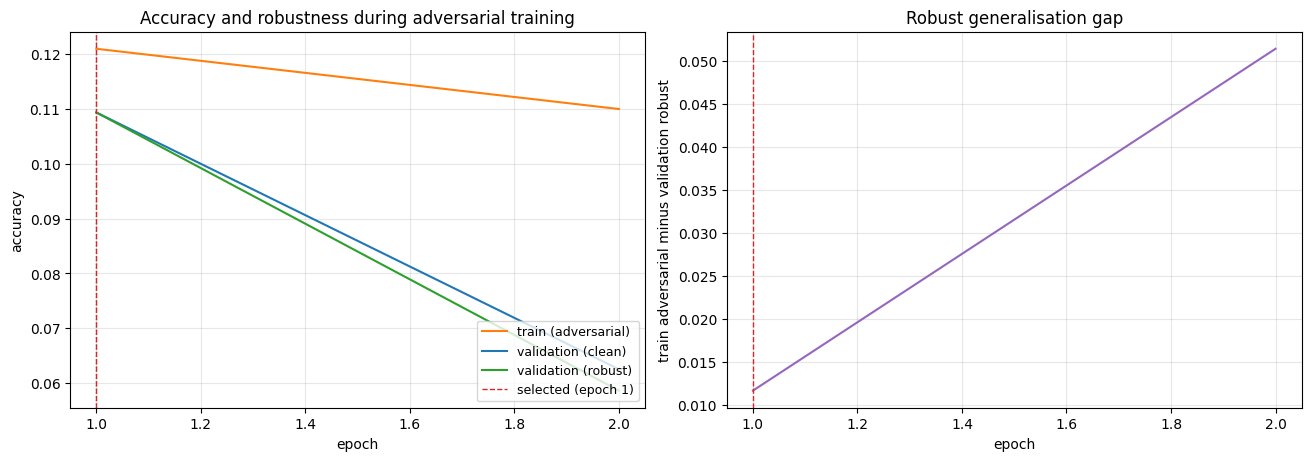

 epoch     lr  train_loss  train_adv_acc  val_clean_acc  val_robust_acc  seconds
     1 0.1000      4.8649         0.1210         0.1094          0.1094   3.7023
     2 0.0100      5.0637         0.1100         0.0625          0.0586   2.5365


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

history = pd.read_csv(result.history_path)
figure_path = OUT_DIR / "adv_training_curves.png"

fig, (ax_acc, ax_gap) = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")

ax_acc.plot(history["epoch"], history["train_adv_acc"], label="train (adversarial)", color="tab:orange")
ax_acc.plot(history["epoch"], history["val_clean_acc"], label="validation (clean)", color="tab:blue")
ax_acc.plot(history["epoch"], history["val_robust_acc"], label="validation (robust)", color="tab:green")
for milestone in config.milestone_epochs():
    ax_acc.axvline(milestone, color="grey", linestyle=":", linewidth=1)
ax_acc.axvline(result.best_epoch, color="tab:red", linestyle="--", linewidth=1,
               label=f"selected (epoch {result.best_epoch})")
ax_acc.set_xlabel("epoch")
ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Accuracy and robustness during adversarial training")
ax_acc.legend(loc="lower right", fontsize=9)
ax_acc.grid(alpha=0.3)

ax_gap.plot(history["epoch"], history["train_adv_acc"] - history["val_robust_acc"], color="tab:purple")
ax_gap.axvline(result.best_epoch, color="tab:red", linestyle="--", linewidth=1)
ax_gap.set_xlabel("epoch")
ax_gap.set_ylabel("train adversarial minus validation robust")
ax_gap.set_title("Robust generalisation gap")
ax_gap.grid(alpha=0.3)

fig.savefig(figure_path, dpi=150)
plt.show()

print(history.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

## 8. Evaluation of the selected checkpoint

Run once, on the test set, using the scoring functions from `experiments/robustness_eval.py` rather than a
reimplementation, so the table is directly comparable to the naturally trained baseline: same 1,000-image subset, same
eps and alpha, same definition of success (correct on clean input, wrong after the attack) and the same norm averaging
over successes only.

Those functions are underscore-prefixed, so importing them crosses a privacy boundary. Duplicating the protocol would be
worse, because the two tables would stop being comparable the moment either definition moved. The follow-up is to
promote them to public names in the module.

Clean accuracy is additionally measured on the full 10,000-image test set, so it is comparable to the baseline's 93.43%
rather than to a subset figure.

Two expectations. Accuracy under PGD should be well above the baseline's 0.0000, and that gap is the result. C&W
accuracy need not reach zero: at a fixed penalty of c=1 it minimises distortion rather than forcing every flip, so read
its success rate rather than its accuracy.

In [8]:
import math

os.environ["CIFAR10_RESNET18_CKPT"] = str(result.checkpoint_path)

from experiments.robustness_eval import (
    ALPHA, CW_C, CW_STEPS, EPS, MODEL_NAME, PGD_RESTARTS, PGD_STEP_COUNTS,
    Evaluation, _clean_predictions, _evaluate, _evaluations, _write_csv,
)

defended = load_model(DEVICE)
loader = build_loader()
clean_preds = _clean_predictions(defended, loader, DEVICE)

table_path = OUT_DIR / "robustness_table_pgd_at.csv"
rows: list[list[str]] = []
for spec in _evaluations(defended):
    res = _evaluate(defended, loader, DEVICE, spec, clean_preds)
    rows.append([
        MODEL_NAME, "pgd_at", spec.attack,
        "" if math.isnan(spec.eps) else f"{spec.eps:.6f}",
        str(spec.steps),
        f"{res.accuracy:.4f}", f"{res.success_rate:.4f}",
        f"{res.mean_linf:.6f}", f"{res.mean_l2:.6f}",
    ])
    tag = f"pgd-{spec.steps}" if spec.attack == "pgd" else spec.attack
    print(f"{tag:>8}: accuracy = {res.accuracy:.4f}, success = {res.success_rate:.4f}, "
          f"mean L-inf = {res.mean_linf:.6f}, mean L2 = {res.mean_l2:.6f}")

_write_csv(rows, table_path)

full_loader = build_loader(num_samples=10_000, batch_size=500)
correct = total = 0
with torch.no_grad():
    for images, labels in full_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        correct += int((defended(images).argmax(dim=1) == labels).sum().item())
        total += labels.size(0)
full_clean_acc = correct / total

print(f"\nfull test clean accuracy: {full_clean_acc:.4f} over {total} images "
      f"(naturally trained baseline: 0.9343)")
print(f"written to {table_path}")
print(f"protocol: eps={EPS:.6f}, alpha={ALPHA:.6f}, pgd steps={PGD_STEP_COUNTS}, restarts={PGD_RESTARTS}, "
      f"cw c={CW_C} steps={CW_STEPS}, 1000 test images")

    none: accuracy = 0.0900, success = 0.0000, mean L-inf = 0.000000, mean L2 = 0.000000
    fgsm: accuracy = 0.0890, success = 0.0111, mean L-inf = 0.031373, mean L2 = 1.738843
  pgd-20: accuracy = 0.0890, success = 0.0111, mean L-inf = 0.031373, mean L2 = 1.630966
  pgd-50: accuracy = 0.0890, success = 0.0111, mean L-inf = 0.031373, mean L2 = 1.647597
   cw_l2: accuracy = 0.0890, success = 0.0111, mean L-inf = 0.028881, mean L2 = 0.151914

full test clean accuracy: 0.1001 over 10000 images (naturally trained baseline: 0.9343)
written to /kaggle/working/results/smoke/robustness_table_pgd_at.csv
protocol: eps=0.031373, alpha=0.007843, pgd steps=(20, 50), restarts=1, cw c=1.0 steps=100, 1000 test images


## 9. Obfuscated-gradient sanity checks

A robustness number without these behind it is not one to report. Athalye, Carlini and Wagner identified five
characteristic behaviours of defences that merely make gradients uninformative; three are checkable here and are run
below.

**Unbounded attack.** With eps set to 1.0 the entire pixel box is reachable, so any model must fall to zero accuracy. A
model that survives has a broken gradient rather than a defence, and this is the single most diagnostic check.

**Monotonicity in eps.** Accuracy must fall as the budget grows. A non-monotone curve means the attack is not finding
what a larger budget makes available.

**Iterative beats single-step.** PGD-50 must be at least as damaging as PGD-20 and both at least as damaging as FGSM,
which the table above already reports.

The two remaining checks are not run here. A black-box or transfer attack must not outperform the white-box one, which
needs the naturally trained checkpoint attached to craft transfer examples from, and random sampling must not beat
gradient ascent. Both are cheap follow-ups and neither is satisfied by anything in this notebook.

Failures are reported rather than raised, since the artefacts above are already written and a failure is a finding to
investigate rather than a reason to discard the run.

In [9]:
SWEEP_EPS = (2 / 255, 4 / 255, 8 / 255, 16 / 255)

sweep: list[tuple[float, float]] = []
for eps_value in SWEEP_EPS:
    spec = Evaluation(
        "pgd", 20, eps_value,
        # eps_value bound as a default argument: Python closures capture by reference, so a
        # bare reference would read the final loop value for every spec.
        lambda x, y, e=eps_value: pgd(defended, x, y, e, e / 4, steps=20),
    )
    accuracy = _evaluate(defended, loader, DEVICE, spec, clean_preds).accuracy
    sweep.append((eps_value, accuracy))
    print(f"pgd-20 at {round(eps_value * 255):>2}/255: accuracy = {accuracy:.4f}")

unbounded_spec = Evaluation(
    "pgd", 50, 1.0, lambda x, y: pgd(defended, x, y, 1.0, 0.1, steps=50),
)
unbounded_acc = _evaluate(defended, loader, DEVICE, unbounded_spec, clean_preds).accuracy
print(f"pgd-50 unbounded (eps=1.0): accuracy = {unbounded_acc:.4f}")

accuracies = [accuracy for _, accuracy in sweep]
pgd_acc = {int(row[4]): float(row[5]) for row in rows if row[2] == "pgd"}
fgsm_acc = next(float(row[5]) for row in rows if row[2] == "fgsm")

checks = {
    "unbounded attack reaches ~0 accuracy": unbounded_acc < 0.05,
    "accuracy is monotone non-increasing in eps": all(a >= b for a, b in zip(accuracies, accuracies[1:])),
    "pgd-50 at least as strong as pgd-20": pgd_acc[50] <= pgd_acc[20] + 1e-9,
    "pgd-20 at least as strong as fgsm": pgd_acc[20] <= fgsm_acc + 1e-9,
}

print()
for description, passed in checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}]  {description}")
if not all(checks.values()):
    print("\nAt least one check failed. Do not report a robustness number from this run until it is explained.")

pgd-20 at  2/255: accuracy = 0.0890
pgd-20 at  4/255: accuracy = 0.0890
pgd-20 at  8/255: accuracy = 0.0890
pgd-20 at 16/255: accuracy = 0.0890
pgd-50 unbounded (eps=1.0): accuracy = 0.0870

  [FAIL]  unbounded attack reaches ~0 accuracy
  [PASS]  accuracy is monotone non-increasing in eps
  [PASS]  pgd-50 at least as strong as pgd-20
  [PASS]  pgd-20 at least as strong as fgsm

At least one check failed. Do not report a robustness number from this run until it is explained.


## 10. Output verification

In [10]:
expected = [
    result.history_path,
    result.checkpoint_path,
    OUT_DIR / "adv_training_config.json",
    figure_path,
    table_path,
]

missing = [path for path in expected if not path.is_file()]
if missing:
    raise RuntimeError(f"Missing expected outputs: {missing}")

for path in expected:
    print(f"{path.stat().st_size / 1024:>10.1f} KB  {path}")

if SMOKE:
    print("\nSMOKE run: these numbers are meaningless. Set SMOKE = False and run again.")
else:
    baseline = {"none": 0.9340, "fgsm": 0.1660, "pgd-20": 0.0000, "pgd-50": 0.0000, "cw_l2": 0.0000}
    defended_acc = {(f"pgd-{row[4]}" if row[2] == "pgd" else row[2]): float(row[5]) for row in rows}
    print("\naccuracy on the 1,000-image test subset, naturally trained -> adversarially trained")
    for key, before in baseline.items():
        after = defended_acc.get(key)
        if after is not None:
            print(f"  {key:>7}: {before:.4f} -> {after:.4f}  ({after - before:+.4f})")

       0.2 KB  /kaggle/working/results/smoke/adv_training_history.csv
   43724.1 KB  /kaggle/working/checkpoints/smoke/resnet18_cifar10_pgd_at.pth
       0.6 KB  /kaggle/working/results/smoke/adv_training_config.json
     131.5 KB  /kaggle/working/results/smoke/adv_training_curves.png
       0.4 KB  /kaggle/working/results/smoke/robustness_table_pgd_at.csv

SMOKE run: these numbers are meaningless. Set SMOKE = False and run again.
